In [ ]:
! conda create -n biomedclip python=3.10 -y
! conda activate biomedclip
! pip install open_clip_torch==2.23.0 transformers==4.35.2 matplotlib

/bin/bash: line 1: conda: command not found
/bin/bash: line 1: conda: command not found
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transform

Import Libaries

In [ ]:
import os
import torch
import numpy as np
from torch import nn
from PIL import Image
import requests
import urllib.request
import tarfile
import random
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.transforms import Resize
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, hamming_loss, average_precision_score, recall_score, precision_score

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


ASL LOSS Function

In [ ]:
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8, disable_torch_grad_focal_loss=True):
        super(AsymmetricLoss, self).__init__()

        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.disable_torch_grad_focal_loss = disable_torch_grad_focal_loss
        self.eps = eps

    def forward(self, x, y):
        """"
        Parameters
        ----------
        x: input logits
        y: targets (multi-label binarized vector)
        """

        # Calculating Probabilities
        x_sigmoid = torch.sigmoid(x)
        xs_pos = x_sigmoid
        xs_neg = 1 - x_sigmoid

        # Asymmetric Clipping
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Basic CE calculation
        los_pos = y * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y) * torch.log(xs_neg.clamp(min=self.eps))
        loss = los_pos + los_neg

        # Asymmetric Focusing
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            if self.disable_torch_grad_focal_loss:
                torch.set_grad_enabled(False)
            pt0 = xs_pos * y
            pt1 = xs_neg * (1 - y)  # pt = p if t > 0 else 1-p
            pt = pt0 + pt1
            one_sided_gamma = self.gamma_pos * y + self.gamma_neg * (1 - y)
            one_sided_w = torch.pow(1 - pt, one_sided_gamma)
            if self.disable_torch_grad_focal_loss:
                torch.set_grad_enabled(True)
            loss *= one_sided_w

        return -loss.mean()

Download DATASETS

In [ ]:
#!/usr/bin/env python3
# Download the 56 zip files in Images_png in batches
import urllib.request

# URLs for the zip files
links = [
    'https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz',
    'https://nihcc.box.com/shared/static/i28rlmbvmfjbl8p2n3ril0pptcmcu9d1.gz',
    'https://nihcc.box.com/shared/static/f1t00wrtdk94satdfb9olcolqx20z2jp.gz',
	'https://nihcc.box.com/shared/static/0aowwzs5lhjrceb3qp67ahp0rd1l1etg.gz',
    'https://nihcc.box.com/shared/static/v5e3goj22zr6h8tzualxfsqlqaygfbsn.gz',
	'https://nihcc.box.com/shared/static/asi7ikud9jwnkrnkj99jnpfkjdes7l6l.gz',
	'https://nihcc.box.com/shared/static/jn1b4mw4n6lnh74ovmcjb8y48h8xj07n.gz',
    'https://nihcc.box.com/shared/static/tvpxmn7qyrgl0w8wfh9kqfjskv6nmm1j.gz',
	'https://nihcc.box.com/shared/static/upyy3ml7qdumlgk2rfcvlb9k6gvqq2pj.gz',
	'https://nihcc.box.com/shared/static/l6nilvfa9cg3s28tqv1qc1olm3gnz54p.gz',
	'https://nihcc.box.com/shared/static/hhq8fkdgvcari67vfhs7ppg2w6ni4jze.gz',
	'https://nihcc.box.com/shared/static/ioqwiy20ihqwyr8pf4c24eazhh281pbu.gz'
]

for idx, link in enumerate(links):
    fn = 'images_%02d.tar.gz' % (idx+1)
    print('downloading'+fn+'...')
    urllib.request.urlretrieve(link, fn)  # download the zip file

print("Download complete. Please check the checksums")

downloadingimages_01.tar.gz...
downloadingimages_02.tar.gz...
downloadingimages_03.tar.gz...
downloadingimages_04.tar.gz...
downloadingimages_05.tar.gz...
downloadingimages_06.tar.gz...
downloadingimages_07.tar.gz...
downloadingimages_08.tar.gz...
downloadingimages_09.tar.gz...
downloadingimages_10.tar.gz...
downloadingimages_11.tar.gz...
downloadingimages_12.tar.gz...
Download complete. Please check the checksums


In [ ]:
tar_root = Path(".")
output_dir = "./nih_images"
image_root = Path(output_dir)
image_root.mkdir(parents=True, exist_ok=True)

for i in range(1, 13):
    tar_path = tar_root / f'images_{i:02d}.tar.gz'
    print("Extracting", tar_path)

    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(image_root)

    os.remove(tar_path)
    print(f"Deleted {tar_path}")

print("All done.")

Extracting images_01.tar.gz


/tmp/ipykernel_1052/1138762215.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(image_root)


Deleted images_01.tar.gz
Extracting images_02.tar.gz
Deleted images_02.tar.gz
Extracting images_03.tar.gz
Deleted images_03.tar.gz
Extracting images_04.tar.gz
Deleted images_04.tar.gz
Extracting images_05.tar.gz
Deleted images_05.tar.gz
Extracting images_06.tar.gz
Deleted images_06.tar.gz
Extracting images_07.tar.gz
Deleted images_07.tar.gz
Extracting images_08.tar.gz
Deleted images_08.tar.gz
Extracting images_09.tar.gz
Deleted images_09.tar.gz
Extracting images_10.tar.gz
Deleted images_10.tar.gz
Extracting images_11.tar.gz
Deleted images_11.tar.gz
Extracting images_12.tar.gz
Deleted images_12.tar.gz
All done.


Match CSV IDs with image paths

In [ ]:
def load_split(csv_path, image_root):
    df = pd.read_csv(csv_path)

    id_to_path = {
        p.name: str(p)
        for p in image_root.rglob("*.png")
    }

    paths = df['id'].map(id_to_path).values
    labels = df.iloc[:, 1:-1].values

    return df, paths, labels

In [ ]:
image_root = Path('/content/nih_images')

train_csv = '/content/miccai2023_nih-cxr-lt_labels_train.csv'
valid_csv = '/content/miccai2023_nih-cxr-lt_labels_val.csv'
test_csv  = '/content/miccai2023_nih-cxr-lt_labels_test.csv'

train_df, train_paths, train_labels = load_split(train_csv, image_root)
valid_df, valid_paths, valid_labels = load_split(valid_csv, image_root)
test_df,  test_paths,  test_labels  = load_split(test_csv,  image_root)

print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))

print("Sample valid paths:", valid_paths[:3])
print("Sample test paths :", test_paths[:3])

Train: 78506
Valid: 12533
Test : 21081
Sample valid paths: ['/content/nih_images/images/00000003_000.png'
 '/content/nih_images/images/00000003_001.png'
 '/content/nih_images/images/00000003_002.png']
Sample test paths : ['/content/nih_images/images/00000013_000.png'
 '/content/nih_images/images/00000013_001.png'
 '/content/nih_images/images/00000013_002.png']


In [ ]:
label_cols = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
    'Infiltration', 'Mass', 'Nodule', 'Pleural Thickening',
    'Pneumonia', 'Pneumothorax','Pneumoperitoneum','Pneumomediastinum',
    'Subcutaneous Emphysema','Tortuous Aorta','Calcification of the Aorta','No Finding']

Define Target labels

In [ ]:
top_labels = ['Infiltration', 'Effusion', 'Nodule']

TRAIN

In [ ]:
has_top = train_df[top_labels].sum(axis=1) > 0

other_labels = [l for l in label_cols if l not in top_labels]
no_other = train_df[other_labels].sum(axis=1) == 0

train_df_filtered = train_df[has_top & no_other].reset_index(drop=True)

train_paths_filtered = train_paths[has_top & no_other]

VALID

In [ ]:
has_top = valid_df[top_labels].sum(axis=1) > 0

other_labels = [l for l in label_cols if l not in top_labels]
no_other = valid_df[other_labels].sum(axis=1) == 0

valid_df_filtered = valid_df[has_top & no_other].reset_index(drop=True)

valid_paths_filtered = valid_paths[has_top & no_other]

TEST

In [ ]:
has_top = test_df[top_labels].sum(axis=1) > 0

other_labels = [l for l in label_cols if l not in top_labels]
no_other = test_df[other_labels].sum(axis=1) == 0

test_df_filtered = test_df[has_top & no_other].reset_index(drop=True)

test_paths_filtered = test_paths[has_top & no_other]

In [ ]:
labels = train_df_filtered[top_labels].values.astype('float32')

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class XrayDataset(Dataset):
    def __init__(self, image_paths, df, label_cols, preprocess):
        self.image_paths = image_paths
        self.labels = df[label_cols].values
        self.preprocess = preprocess

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        #image = self.preprocess(images=image, return_tensors="pt")["pixel_values"][0]
        image = self.preprocess(image)

        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        return image, label

Our pre-trained model

In [ ]:
import open_clip
model, _ , preprocess = open_clip.create_model_and_transforms('hf-hub:luhuitong/CLIP-ViT-L-14-448px-MedICaT-ROCO')
tokenizer = open_clip.get_tokenizer('hf-hub:luhuitong/CLIP-ViT-L-14-448px-MedICaT-ROCO')

Other clip model

In [ ]:
from open_clip import create_model_from_pretrained, get_tokenizer
import torch
from urllib.request import urlopen
from PIL import Image

# import model, processor and tokenizer
model, processor = create_model_from_pretrained('hf-hub:xcwangpsu/MedCSP_clip')
tokenizer_text = get_tokenizer('hf-hub:xcwangpsu/MedCSP_clip')

In [ ]:
import requests
from PIL import Image
import matplotlib.pyplot as plt

from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("flaviagiammarino/pubmed-clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("flaviagiammarino/pubmed-clip-vit-base-patch32")

In [ ]:
from PIL import Image
import requests

from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [ ]:
import torch
from urllib.request import urlopen
from PIL import Image
from open_clip import create_model_from_pretrained, get_tokenizer

# Load the model and config files from the Hugging Face Hub
model, preprocess = create_model_from_pretrained('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
tokenizer = get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')

Using gpu and freeze parameters

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
for p in model.parameters():
    p.requires_grad = False

In [ ]:
import torch
import random
import numpy as np
from torch.utils.data import DataLoader

# Fix random seed
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# For deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Create generator for DataLoader shuffle
g = torch.Generator()
g.manual_seed(seed)


train_dataset = XrayDataset(
    train_paths_filtered,
    train_df_filtered,
    top_labels,
    preprocess
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    generator=g
)


valid_dataset = XrayDataset(
    valid_paths_filtered,
    valid_df_filtered,
    top_labels,
    preprocess
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    generator=g
)


test_dataset = XrayDataset(
    test_paths_filtered,
    test_df_filtered,
    top_labels,
    preprocess
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    generator=g
)

Next are some kinds of adapter that we tried

In [ ]:
def FCAdapter(image_features, text_features, alpha=15):
    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)

    cos_sim = torch.matmul(image_features, text_features.T)  # [B, 3]

    mean_cos = torch.tensor(
        [0.2630262, 0.26650873, 0.25455144],
        device=cos_sim.device,
        dtype=cos_sim.dtype
    ).unsqueeze(0)

    cos = cos_sim - mean_cos

    probs = torch.sigmoid(alpha * cos)

    return probs, cos

In [ ]:
def FCAdapter(image_features, text_features, alpha = 5):
    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)

    cos_sim = torch.matmul(image_features, text_features.T)#.squeeze(1)
    probs = torch.sigmoid(alpha * cos_sim)
    return probs, cos_sim

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FCAdapter(nn.Module):
    def __init__(self, img_dim=768, txt_dim=768, hidden_dim=768, num_labels=3):
        super().__init__()

        #image / text projection
        self.image_proj = nn.Linear(img_dim, hidden_dim)
        self.text_proj  = nn.Linear(txt_dim, hidden_dim)

        #learnable temperature
        self.alpha = nn.Parameter(torch.tensor(15.0, dtype=torch.float))
        #self.bias = nn.Parameter(torch.zeros(num_labels))
        #learnable class-wise bias
        self.bias = nn.Parameter(
            torch.tensor([0.2577, 0.2728, 0.2383],
             #[0.27785128, 0.25445756, 0.25266066],
             #[0.25362316, 0.27696162, 0.2707817,  0.24556202, 0.27690566, 0.28631553,0.26778105, 0.26038176, 0.26168174],
                dtype=torch.float
            )
        )

    def forward(self, image_features, text_features):
        """
        image_features: (B, img_dim)
        text_features:  (num_labels, txt_dim)
        """

        # ===== projection =====
        img = self.image_proj(image_features)      # (B, D)
        txt = self.text_proj(text_features)        # (num_labels, D)

        # ===== normalize =====
        img = F.normalize(img, dim=-1)
        txt = F.normalize(txt, dim=-1)

        # ===== cosine similarity =====
        cos_sim = torch.matmul(img, txt.T)         # (B, num_labels)

        # ===== learnable class-wise bias =====
        logits = self.alpha * (cos_sim - self.bias)

        # ===== sigmoid =====
        #probs = torch.sigmoid(logits)
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FCAdapter(nn.Module):
    def __init__(
        self,
        img_dim=768,
        txt_dim=768,
        hidden_dim=256,     # bottleneck dim（优化④）
        num_labels=9
    ):
        super().__init__()

        # ===== bottleneck adapter =====
        self.image_proj = nn.Sequential(
            nn.Linear(img_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, img_dim)
        )

        self.text_proj = nn.Sequential(
            nn.Linear(txt_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, txt_dim)
        )

        self.alpha = nn.Parameter(torch.tensor(15.0, dtype=torch.float))

        self.bias = nn.Parameter(
            torch.tensor([0.25362316, 0.27696162, 0.2707817,  0.24556202, 0.27690566, 0.28631553,
 0.26778105, 0.26038176, 0.26168174],#[0.27785128, 0.25445756, 0.25266066],
                dtype=torch.float
            )
        )

    def forward(self, image_features, text_features):
        """
        image_features: (B, img_dim)
        text_features:  (num_labels, txt_dim)
        """

        # ===== residual adapter（优化①）=====
        img_res = self.image_proj(image_features)
        txt_res = self.text_proj(text_features)


        # ===== normalize =====
        img_res= F.normalize(img_res, dim=-1)
        txt_res = F.normalize(txt_res, dim=-1)

        # ===== cosine similarity =====
        cos_sim = torch.matmul(img_res, txt_res.T)

        # ===== per-class temperature + bias =====
        logits = self.alpha * (cos_sim - self.bias)

        probs = torch.sigmoid(logits)
        return probs

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FCAdapter(nn.Module):
    def __init__(
        self,
        clip_model,
        prompt_len=4,
        embed_dim=768,
    ):
        super().__init__()

        self.clip = clip_model
        for p in self.clip.parameters():
            p.requires_grad = False   # freeze CLIP

        # ===== learnable visual prompts =====
        self.visual_prompts = nn.Parameter(
            torch.randn(prompt_len, embed_dim) * 0.02
        )

        # ===== learnable text prompts =====
        self.text_prompts = nn.Parameter(
            torch.randn(prompt_len, embed_dim) * 0.02
        )

        # ===== prompt gating (让模型控制prompt强度) =====
        self.visual_gate = nn.Parameter(torch.tensor(1.0))
        self.text_gate   = nn.Parameter(torch.tensor(1.0))

        # ===== learnable temperature =====
        self.alpha = nn.Parameter(torch.tensor(15.0))


    def forward(self, image_embeds, text_embeds):
        """
        image_embeds: (B, D)
        text_embeds:  (num_labels, D)
        """

        # ===== prompt aggregation =====
        visual_prompt = self.visual_prompts.mean(dim=0)
        text_prompt   = self.text_prompts.mean(dim=0)

        # ===== gated injection =====
        img = image_embeds + self.visual_gate * visual_prompt
        txt = text_embeds  + self.text_gate   * text_prompt

        # ===== normalize =====
        img = F.normalize(img, dim=-1)
        txt = F.normalize(txt, dim=-1)

        # ===== cosine similarity =====
        cos_sim = torch.matmul(img, txt.T)

        # ===== temperature scaling =====
        logits = self.alpha * cos_sim

        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        self.classifier = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, image_feature, text_feature):
        image = image_feature.unsqueeze(1)   # [B, 1, D]
        text  = text_feature.unsqueeze(0)    # [1, C, D]

        # dual branch
        h_img = self.img_mlp(image)   # [B,1,D]
        h_txt = self.txt_mlp(text)    # [1,C,D]

        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        fused = h_img * h_txt   # [B, C, D]
        logits = self.classifier(fused).squeeze(-1)  # [B, C]
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        # image branch
        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # text branch
        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        self.alpha = nn.Parameter(torch.tensor(15.0, dtype=torch.float))

        self.bias = nn.Parameter(
            torch.tensor([0.2630262,  0.26650873, 0.25455144],
                dtype=torch.float
            )
        )


    def forward(self, image_feature, text_feature):

        # ===== dual branch =====
        h_img = self.img_mlp(image_feature)   # [B, D]
        h_txt = self.txt_mlp(text_feature)    # [C, D]

        # ===== normalize (very important) =====
        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        # ===== cosine similarity via matmul =====
        cos_sim = torch.matmul(h_img, h_txt.T)   # [B, C]

        logits = self.alpha * (cos_sim - self.bias)

        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=512, hidden_dim=512):
        super().__init__()

        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        self.classifier = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, image_feature, text_feature):
        image = image_feature.unsqueeze(1)   # [B, 1, D]
        text  = text_feature.unsqueeze(0)    # [1, C, D]

        # dual branch
        h_img = self.img_mlp(image)   # [B,1,D]
        h_txt = self.txt_mlp(text)    # [1,C,D]

        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        fused = h_img * h_txt   # [B, C, D]
        logits = self.classifier(fused).squeeze(-1)  # [B, C]
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # input dim 改成 2*dim
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, image_feature, text_feature):

        image = image_feature.unsqueeze(1)   # [B,1,D]
        text  = text_feature.unsqueeze(0)    # [1,C,D]

        # dual branch
        h_img = self.img_mlp(image)
        h_txt = self.txt_mlp(text)

        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        # expand to [B,C,D]
        h_img_expand = h_img.expand(-1, h_txt.size(1), -1)
        h_txt_expand = h_txt.expand(h_img.size(0), -1, -1)

        # concatenation
        fused = torch.cat([h_img_expand, h_txt_expand], dim=-1)

        # [B,C,2D] -> [B,C]
        logits = self.classifier(fused).squeeze(-1)

        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        # image branch
        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # text branch
        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # mul + add = 2D
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, image_feature, text_feature):

        # image_feature: [B, D]
        # text_feature : [C, D]

        # expand dimension
        image = image_feature.unsqueeze(1)   # [B,1,D]
        text  = text_feature.unsqueeze(0)    # [1,C,D]

        # dual branch projection
        h_img = self.img_mlp(image)
        h_txt = self.txt_mlp(text)

        # normalization
        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        # expand to [B,C,D]
        h_img_expand = h_img.expand(-1, h_txt.size(1), -1)
        h_txt_expand = h_txt.expand(h_img.size(0), -1, -1)

        # ===== fusion =====

        # interaction feature
        mul_feature = h_img_expand * h_txt_expand

        # semantic feature
        add_feature = h_img_expand + h_txt_expand

        # concatenate
        fused = torch.cat(
            [mul_feature, add_feature],
            dim=-1
        )   # [B,C,2D]

        # classification
        logits = self.classifier(fused).squeeze(-1)

        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        # image branch
        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # text branch
        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # mul + diff = 2D
        self.classifier = nn.Sequential(
            nn.Linear(dim , hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, image_feature, text_feature):
        image = image_feature.unsqueeze(1)   # [B,1,D]
        text  = text_feature.unsqueeze(0)    # [1,C,D]

        # dual branch projection
        h_img = self.img_mlp(image)
        h_txt = self.txt_mlp(text)

        # normalize
        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        # expand to [B,C,D]
        h_img_expand = h_img.expand(-1, h_txt.size(1), -1)
        h_txt_expand = h_txt.expand(h_img.size(0), -1, -1)


        max_feature = torch.maximum(
            h_img_expand,
            h_txt_expand
        )

        # classification
        logits = self.classifier(max_feature).squeeze(-1)
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        # image branch
        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # text branch
        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # mul + diff = 2D
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2 , hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, image_feature, text_feature):
        image = image_feature.unsqueeze(1)   # [B,1,D]
        text  = text_feature.unsqueeze(0)    # [1,C,D]

        # dual branch projection
        h_img = self.img_mlp(image)
        h_txt = self.txt_mlp(text)

        # normalize
        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        # expand to [B,C,D]
        h_img_expand = h_img.expand(-1, h_txt.size(1), -1)
        h_txt_expand = h_txt.expand(h_img.size(0), -1, -1)

        # ===== recommended fusion =====

        # interaction feature
        mul_feature = h_img_expand * h_txt_expand
        # min-max features
        min_feature = torch.minimum(
            h_img_expand,
            h_txt_expand
        )
        # concatenate
        fused = torch.cat(
            [mul_feature, min_feature],
            dim=-1
        )

        # classification
        logits = self.classifier(fused).squeeze(-1)
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        # image branch
        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # text branch
        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # mul + diff = 2D
        self.classifier = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, image_feature, text_feature):
        image = image_feature.unsqueeze(1)   # [B,1,D]
        text  = text_feature.unsqueeze(0)    # [1,C,D]

        # dual branch projection
        h_img = self.img_mlp(image)
        h_txt = self.txt_mlp(text)

        # normalize
        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        # expand to [B,C,D]
        h_img_expand = h_img.expand(-1, h_txt.size(1), -1)
        h_txt_expand = h_txt.expand(h_img.size(0), -1, -1)

        # ===== recommended fusion =====


        # difference feature
        diff_feature = torch.abs(h_img_expand - h_txt_expand)
        # classification
        logits = self.classifier(diff_feature).squeeze(-1)
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        # image branch
        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # text branch
        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # mul + diff = 2D
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, image_feature, text_feature):
        image = image_feature.unsqueeze(1)   # [B,1,D]
        text  = text_feature.unsqueeze(0)    # [1,C,D]

        # dual branch projection
        h_img = self.img_mlp(image)
        h_txt = self.txt_mlp(text)

        # normalize
        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        # expand to [B,C,D]
        h_img_expand = h_img.expand(-1, h_txt.size(1), -1)
        h_txt_expand = h_txt.expand(h_img.size(0), -1, -1)

        # ===== recommended fusion =====

        # interaction feature
        mul_feature = h_img_expand * h_txt_expand

        # difference feature
        diff_feature = torch.abs(h_img_expand - h_txt_expand)

        # fusion
        fused = torch.cat(
            [mul_feature, diff_feature],
            dim=-1
        )   # [B,C,2D]

        # classification
        logits = self.classifier(fused).squeeze(-1)
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        # image branch
        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # text branch
        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # mul(D) + squared_diff(D) = 2D
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, image_feature, text_feature):

        # image_feature: [B, D]
        # text_feature : [C, D]

        image = image_feature.unsqueeze(1)   # [B,1,D]
        text = text_feature.unsqueeze(0)     # [1,C,D]

        # dual branch projection
        h_img = self.img_mlp(image)
        h_txt = self.txt_mlp(text)

        # normalize
        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        # expand to [B,C,D]
        h_img_expand = h_img.expand(-1, h_txt.size(1), -1)
        h_txt_expand = h_txt.expand(h_img.size(0), -1, -1)

        # similarity feature
        mul_feature = h_img_expand * h_txt_expand

        # squared difference feature
        sqdiff_feature = (
            h_img_expand - h_txt_expand
        ) ** 2

        # fusion
        fused = torch.cat(
            [
                mul_feature,
                sqdiff_feature
            ],
            dim=-1
        )  # [B,C,2D]

        # classification
        logits = self.classifier(fused).squeeze(-1)

        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        # image branch
        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # text branch
        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # mul(D) + diff(D) + cosine(1)
        fusion_dim = dim * 2 + 1

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, image_feature, text_feature):

        # image_feature: [B,D]
        # text_feature : [C,D]

        image = image_feature.unsqueeze(1)   # [B,1,D]
        text = text_feature.unsqueeze(0)     # [1,C,D]

        # dual branch projection
        h_img = self.img_mlp(image)
        h_txt = self.txt_mlp(text)

        # normalize
        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        # expand
        h_img_expand = h_img.expand(
            -1,
            h_txt.size(1),
            -1
        )   # [B,C,D]

        h_txt_expand = h_txt.expand(
            h_img.size(0),
            -1,
            -1
        )   # [B,C,D]

        # element-wise similarity
        mul_feature = (
            h_img_expand * h_txt_expand
        )   # [B,C,D]

        # element-wise difference
        diff_feature = torch.abs(
            h_img_expand - h_txt_expand
        )   # [B,C,D]

        # global cosine similarity
        cos_feature = (
            h_img_expand * h_txt_expand
        ).sum(
            dim=-1,
            keepdim=True
        )   # [B,C,1]

        # fusion
        fused = torch.cat(
            [
                mul_feature,
                diff_feature,
                cos_feature
            ],
            dim=-1
        )   # [B,C,1537]

        # classification
        logits = self.classifier(
            fused
        ).squeeze(-1)

        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        # image branch
        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # text branch
        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # mul(D) + diff(D) + cosine(1)
        fusion_dim = dim * 2 + 1

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, image_feature, text_feature):

        # image_feature: [B,D]
        # text_feature : [C,D]

        image = image_feature.unsqueeze(1)   # [B,1,D]
        text = text_feature.unsqueeze(0)     # [1,C,D]

        # dual branch projection
        h_img = self.img_mlp(image)
        h_txt = self.txt_mlp(text)

        # normalize
        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        # expand
        h_img_expand = h_img.expand(
            -1,
            h_txt.size(1),
            -1
        )   # [B,C,D]

        h_txt_expand = h_txt.expand(
            h_img.size(0),
            -1,
            -1
        )   # [B,C,D]

        # element-wise similarity
        mul_feature = (
            h_img_expand * h_txt_expand
        )   # [B,C,D]

        # element-wise difference
        diff_feature = torch.abs(
            h_img_expand - h_txt_expand
        )   # [B,C,D]

        # global cosine similarity
        cos_feature = (
            h_img_expand * h_txt_expand
        ).sum(
            dim=-1,
            keepdim=True
        )   # [B,C,1]

        # fusion
        fused = torch.cat(
            [
                mul_feature,
                diff_feature,
                cos_feature
            ],
            dim=-1
        )   # [B,C,1537]

        # classification
        logits = self.classifier(
            fused
        ).squeeze(-1)

        return logits

This Adapter is the one that has got the best auc of nodule so far

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualBranchAdapter(nn.Module):
    def __init__(self, dim=768, hidden_dim=512):
        super().__init__()

        # image branch
        self.img_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # text branch
        self.txt_mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

        # mul(D) + min(D) + max(D) = 3D
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, image_feature, text_feature):

        # image_feature: [B,D]
        # text_feature : [C,D]

        image = image_feature.unsqueeze(1)
        text = text_feature.unsqueeze(0)

        # projection
        h_img = self.img_mlp(image)
        h_txt = self.txt_mlp(text)

        # normalize
        h_img = F.normalize(h_img, dim=-1)
        h_txt = F.normalize(h_txt, dim=-1)

        # expand
        h_img_expand = h_img.expand(
            -1,
            h_txt.size(1),
            -1
        )

        h_txt_expand = h_txt.expand(
            h_img.size(0),
            -1,
            -1
        )

        # interaction
        mul_feature = (
            h_img_expand * h_txt_expand
        )

        # min-max features
        min_feature = torch.minimum(
            h_img_expand,
            h_txt_expand
        )

        max_feature = torch.maximum(
            h_img_expand,
            h_txt_expand
        )
        # element-wise difference
        diff_feature = torch.abs(
            h_img_expand - h_txt_expand
        )   # [B,C,D]

        # fusion
        fused = torch.cat(
            [
                mul_feature,
                diff_feature
            ],
            dim=-1
        )  # [B,C,3D]

        # classifier
        logits = self.classifier(
            fused
        ).squeeze(-1)

        return logits

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, hamming_loss, confusion_matrix, average_precision_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from google.colab import drive
batch_loss = 0.0
num_labels = 3
criterion = AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05, disable_torch_grad_focal_loss=True)

label_names = ['Infiltration', 'Effusion', 'Nodule']
num_epochs = 1

patience = 3

train_losses, val_losses = [], []
train_f1_scores, val_f1_scores = [], []
train_hamming_losses, val_hamming_losses = [], []
train_accuracies, val_accuracies = [], []

train_Accs, valid_Accs = [], []

train_label_precisions = {}
train_label_recalls = {}
train_label_hamming_losses = {}
train_label_f1_scores = {}
train_label_specificities = {}
train_label_aucs = {}
train_label_maps = {}

val_label_precisions = {}
val_label_recalls = {}
val_label_hamming_losses = {}
val_label_f1_scores = {}
val_label_specificities = {}
val_label_aucs = {}
val_label_maps = {}

num_classes = 3
Adapter = DualBranchAdapter()
optimizer = torch.optim.Adam(Adapter.parameters(), lr=3e-4)

# ======= Early Stopping =======
best_val_loss = float("inf")
patience = 5
counter = 0

early_stop = False


model.to(device)
Adapter.to(device)
# ======= Only did once =======
with torch.no_grad():
    label_texts = [f"A chest radiograph with {i}, characterized by specific radiological features in the pulmonary area, affecting the thoracic cavity." for i in label_names]
    text_tokens = tokenizer(label_texts, context_length=77).to(device)
    text_features = model.encode_text(text_tokens)  # (num_labels, 768)
    text_features = F.normalize(text_features, dim=-1)


for epoch in range(num_epochs):
    model.train()
    Adapter.train()
    train_loss = 0.0

    y_train_true, y_train_pred = [], []
    train_label_accuracies = {f"label_{i}": [] for i in range(num_labels)}

    for images, labels in train_loader:
        images = images.to(device)     # (B, 3, 224, 224)
        labels = labels.to(device)     # (B, num_labels)

        image_features = model.encode_image(images)  # (B, 768)
        image_features = F.normalize(image_features, dim=-1)
        # ---- Adapter 计算 ----
        predictions = Adapter(image_features, text_features)  # (B, num_labels)

        # ---- Loss & Backprop ----
        loss = criterion(predictions, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # ---- 记录结果 ----
        train_loss += loss.item()
        predictions = torch.sigmoid(predictions)
        y_train_pred.append(predictions.detach().cpu().numpy())
        y_train_true.append(labels.cpu().numpy())
    y_train_pred = np.concatenate(y_train_pred, axis=0)
    y_train_true = np.concatenate(y_train_true, axis=0)
    y_train_pred_prob = y_train_pred.copy()

    y_train_pred = (y_train_pred > 0.5).astype(int)

    train_subset_acc = accuracy_score(y_train_true, y_train_pred)
    train_Acc = accuracy_score(y_train_true.ravel(), y_train_pred.ravel())
    train_precision = precision_score(y_train_true, y_train_pred, average="micro", zero_division=0)
    train_recall = recall_score(y_train_true, y_train_pred, average="micro", zero_division=0)
    train_f1 = f1_score(y_train_true, y_train_pred, average="micro")
    train_hamming = hamming_loss(y_train_true, y_train_pred)
    train_mAP = average_precision_score(y_train_true, y_train_pred_prob, average="macro")

    tn, fp, fn, tp = confusion_matrix(y_train_true.ravel(), y_train_pred.ravel(), labels=[0, 1]).ravel()
    train_specificity = tn / (tn + fp + 1e-7)

    #calculate evaluation matrics for each label
    for i in range(num_labels):
        train_label_acc = accuracy_score(y_train_true[:, i], y_train_pred[:, i])
        train_label_accuracies[f"label_{i}"].append(train_label_acc)

        #precision & recall
        train_label_prec = precision_score(y_train_true[:, i], y_train_pred[:, i], zero_division=0)
        train_label_rec = recall_score(y_train_true[:, i], y_train_pred[:, i], zero_division=0)

        train_label_precisions[f"label_{i}"] = train_label_prec
        train_label_recalls[f"label_{i}"] = train_label_rec

        #hamming loss
        train_label_hamming = hamming_loss(y_train_true[:, i], y_train_pred[:, i])
        train_label_hamming_losses[f"label_{i}"] = train_label_hamming

        # F1 Score
        train_label_f1 = f1_score(y_train_true[:, i], y_train_pred[:, i], zero_division=0)
        train_label_f1_scores[f"label_{i}"] = train_label_f1
        # Specificity
        try:
            tn, fp, fn, tp = confusion_matrix(y_train_true[:, i], y_train_pred[:, i], labels=[0, 1]).ravel()
            train_label_spec = tn / (tn + fp + 1e-7)
        except:
            train_label_spec = float('nan')
        train_label_specificities[f"label_{i}"] = train_label_spec

        # AUC
        try:
            train_label_auc = roc_auc_score(y_train_true[:, i], y_train_pred_prob[:, i])
        except ValueError:
            train_label_auc = float('nan')
        train_label_aucs[f"label_{i}"] = train_label_auc

        try:
            train_label_map = average_precision_score(y_train_true[:, i], y_train_pred[:, i])
        except ValueError:
            train_label_map = float('nan')
        train_label_maps[f"label_{i}"] = train_label_map

        # Hamming Loss
        train_label_hamming = hamming_loss(y_train_true[:, i], y_train_pred[:, i])
        train_label_hamming_losses[f"label_{i}"] = train_label_hamming

    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    train_Accs.append(train_Acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}")

    # ======= 在验证前（与 train 阶段共用同一 text_features） =======
    model.eval()
    Adapter.eval()

    val_loss = 0.0
    y_val_true, y_val_pred = [], []

    # 记录每个标签的指标
    val_label_accuracies = {f"label_{i}": [] for i in range(num_labels)}


    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device)

            # ---- 图像特征 ----

            image_features = model.encode_image(images)
            image_features = F.normalize(image_features, dim=-1)

            # ---- Adapter 预测 ----
            predictions = Adapter(image_features, text_features)  # (B, num_labels)
            loss = criterion(predictions, labels)
            val_loss += loss.item()
            predictions = torch.sigmoid(predictions)

            # ---- 保存结果 ----
            y_val_pred.append(predictions.detach().cpu().numpy())
            y_val_true.append(labels.cpu().numpy())

    # ======= 拼接所有批次结果 =======
    y_val_pred = np.concatenate(y_val_pred, axis=0)
    y_val_true = np.concatenate(y_val_true, axis=0)
    y_val_pred_prob = y_val_pred.copy()
    y_val_pred = (y_val_pred > 0.5).astype(int)

    # ======= 计算整体指标 =======
    val_subset_acc = accuracy_score(y_val_true, y_val_pred)
    val_Acc = accuracy_score(y_val_true.ravel(), y_val_pred.ravel())
    val_precision = precision_score(y_val_true, y_val_pred, average="micro", zero_division=0)
    val_recall = recall_score(y_val_true, y_val_pred, average="micro", zero_division=0)
    val_f1 = f1_score(y_val_true, y_val_pred, average="micro")
    val_hamming = hamming_loss(y_val_true, y_val_pred)
    val_mAP = average_precision_score(y_val_true, y_val_pred_prob, average="macro")

    tn, fp, fn, tp = confusion_matrix(y_val_true.ravel(), y_val_pred.ravel(), labels=[0, 1]).ravel()
    val_specificity = tn / (tn + fp + 1e-7)

    # ======= Evaluation for each label =======
    for i in range(num_labels):
        val_label_acc = accuracy_score(y_val_true[:, i], y_val_pred[:, i])
        val_label_accuracies[f"label_{i}"].append(val_label_acc)

        val_label_prec = precision_score(y_val_true[:, i], y_val_pred[:, i], zero_division=0)
        val_label_rec = recall_score(y_val_true[:, i], y_val_pred[:, i], zero_division=0)
        val_label_precisions[f"label_{i}"] = val_label_prec
        val_label_recalls[f"label_{i}"] = val_label_rec

        val_label_f1 = f1_score(y_val_true[:, i], y_val_pred[:, i], zero_division=0)
        val_label_f1_scores[f"label_{i}"] = val_label_f1

        try:
            tn, fp, fn, tp = confusion_matrix(y_val_true[:, i], y_val_pred[:, i], labels=[0, 1]).ravel()
            val_label_spec = tn / (tn + fp + 1e-7)
        except:
            val_label_spec = float('nan')
        val_label_specificities[f"label_{i}"] = val_label_spec

        try:
            val_label_auc = roc_auc_score(y_val_true[:, i], y_val_pred_prob[:, i])
        except ValueError:
            val_label_auc = float('nan')
        val_label_aucs[f"label_{i}"] = val_label_auc

        try:
            val_label_map = average_precision_score(y_val_true[:, i], y_val_pred[:, i])
        except ValueError:
            val_label_map = float('nan')
        val_label_maps[f"label_{i}"] = val_label_map

        val_label_hamming = hamming_loss(y_val_true[:, i], y_val_pred[:, i])
        val_label_hamming_losses[f"label_{i}"] = val_label_hamming
    val_loss /= len(valid_loader)
    val_losses.append(val_loss)
    valid_Accs.append(val_Acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
          f"Train subset acc: {train_subset_acc:.4f}, Val Acc: {val_subset_acc:.4f}, "
          f"Train Acc: {train_Acc:.4f}, Val Acc: {val_Acc:.4f}, "
          f"Train mAP: {train_mAP:.4f}, Val mAP: {val_mAP:.4f}, "
          f"Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, "
          f"Train Hamming: {train_hamming:.4f}, Val Hamming: {val_hamming:.4f}"
          f"Train spec: {train_specificity}, Val spec: {val_specificity}"
          f"Train_recall: {train_recall}, Val recall: {val_recall}"
          f"Train_precision: {train_precision}, Val precision: {val_precision}")
    print("========== Per-Label Training Metrics ==========")
    for i in range(num_labels):
        print(f"[Label {i}]")
        print(f"  Accuracy        : {train_label_accuracies[f'label_{i}'][-1]:.4f}")
        print(f"  Precision       : {train_label_precisions[f'label_{i}']:.4f}")
        print(f"  Recall (Sens)   : {train_label_recalls[f'label_{i}']:.4f}")
        print(f"  Specificity     : {train_label_specificities[f'label_{i}']:.4f}")
        print(f"  F1 Score        : {train_label_f1_scores[f'label_{i}']:.4f}")
        print(f"  AUC             : {train_label_aucs[f'label_{i}']:.4f}")
        print(f"  mAP             : {train_label_maps[f'label_{i}']:.4f}")
        print(f"  Hamming Loss    : {train_label_hamming_losses[f'label_{i}']:.4f}")
        print("")

    print("========== Per-Label Validation Metrics ==========")
    for i in range(num_labels):
        print(f"[Label {i}]")
        print(f"  Accuracy        : {val_label_accuracies[f'label_{i}'][-1]:.4f}")
        print(f"  Precision       : {val_label_precisions[f'label_{i}']:.4f}")
        print(f"  Recall (Sens)   : {val_label_recalls[f'label_{i}']:.4f}")
        print(f"  Specificity     : {val_label_specificities[f'label_{i}']:.4f}")
        print(f"  F1 Score        : {val_label_f1_scores[f'label_{i}']:.4f}")
        print(f"  AUC             : {val_label_aucs[f'label_{i}']:.4f}")
        print(f"  mAP             : {val_label_maps[f'label_{i}']:.4f}")
        print(f"  Hamming Loss    : {val_label_hamming_losses[f'label_{i}']:.4f}")

# ======= Early Stopping 判断 =======
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      counter = 0

      # 保存最优模型
      torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'adapter_state_dict': Adapter.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_losses,
        'train_acc': train_Accs,
        'valid_loss': val_losses,
        'valid_acc': valid_Accs,
      }, "/content/drive/MyDrive/muldiff.pth")

      print(f"Validation loss improved. Model saved.")
    else:
      counter += 1
      print(f"No improvement for {counter}/{patience} epochs.")

      if counter >= patience:
        print("Early stopping triggered.")
        early_stop = True

    if early_stop:
      break


Epoch [1/1] - Train Loss: 0.1019
Epoch [1/1], Train Loss: 0.1019, Val Loss: 0.0948, Train subset acc: 0.0220, Val Acc: 0.0871, Train Acc: 0.4598, Val Acc: 0.5339, Train mAP: 0.6531, Val mAP: 0.7117, Train F1: 0.5801, Val F1: 0.6222, Train Hamming: 0.5402, Val Hamming: 0.4661Train spec: 0.1393581429922789, Val spec: 0.24674519528063407Train_recall: 0.9866250254599769, Val recall: 0.9797882579403272Train_precision: 0.4108682744776499, Val precision: 0.45588893864755936
========== Per-Label Training Metrics ==========
[Label 0]
  Accuracy        : 0.6331
  Precision       : 0.6334
  Recall (Sens)   : 0.9988
  Specificity     : 0.0013
  F1 Score        : 0.7752
  AUC             : 0.7085
  mAP             : 0.6334
  Hamming Loss    : 0.3669

[Label 1]
  Accuracy        : 0.4841
  Precision       : 0.3491
  Recall (Sens)   : 0.9612
  Specificity     : 0.2969
  F1 Score        : 0.5121
  AUC             : 0.8430
  mAP             : 0.3464
  Hamming Loss    : 0.5159

[Label 2]
  Accuracy     

RuntimeError: Parent directory /content/drive/MyDrive does not exist.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch

ckpt_path = "/content/drive/MyDrive/mulminmaxepoch4.pth"

checkpoint = torch.load(ckpt_path, map_location=device)

#模型参数
model.load_state_dict(checkpoint['model_state_dict'])

#Adapter 参数
Adapter.load_state_dict(checkpoint['adapter_state_dict'])

#optimizer（如果要继续训练）
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

#训练状态
start_epoch = checkpoint['epoch']

train_losses = checkpoint['train_loss']
train_Accs   = checkpoint['train_acc']
val_losses   = checkpoint['valid_loss']
valid_Accs   = checkpoint['valid_acc']

print(f"Loaded checkpoint from epoch {start_epoch}")

Loaded checkpoint from epoch 4


In [ ]:
model.eval()
cos_sim_all = []
#model_text.eval()
#FCAdapter.eval()
num_labels = 3
y_test_true, y_test_pred = [], []
labels_all = []

test_label_accuracies = {f"label_{i}": [] for i in range(num_labels)}
test_label_precisions = {}
test_label_recalls = {}
test_label_f1_scores = {}
test_label_specificities = {}
test_label_aucs = {}
test_label_maps = {}
test_label_hamming_losses = {}
model.to(device)
with torch.no_grad():
    label_texts = [f"A chest radiograph with {i}, characterized by specific radiological features in the pulmonary area, affecting the thoracic cavity." for i in label_names]

    inputs = processor(
        text=label_texts,
        return_tensors="pt",
        padding=True
    ).to(device)

    text_features_tensor = model.get_text_features(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        image_features_tensor = model.get_image_features(pixel_values=images)

        predictions =  Adapter(image_features_tensor, text_features_tensor)

        # ---- 保存结果 ----
        y_test_pred.append(predictions.detach().cpu().numpy())
        y_test_true.append(labels.cpu().numpy())
# ======= 拼接所有批次结果 =======
y_test_pred = np.concatenate(y_test_pred, axis=0)
y_test_true = np.concatenate(y_test_true, axis=0)
y_test_pred_prob = y_test_pred.copy()
y_test_pred = (y_test_pred_prob > 0.5).astype(int)

# ======= 计算整体指标 =======
test_subset_acc = accuracy_score(y_test_true, y_test_pred)
test_Acc = accuracy_score(y_test_true.ravel(), y_test_pred.ravel())
test_precision = precision_score(y_test_true, y_test_pred, average="micro", zero_division=0)
test_recall = recall_score(y_test_true, y_test_pred, average="micro", zero_division=0)
test_f1 = f1_score(y_test_true, y_test_pred, average="micro")
test_hamming = hamming_loss(y_test_true, y_test_pred)
test_mAP = average_precision_score(y_test_true, y_test_pred_prob, average="macro")
test_auc = roc_auc_score(y_test_true, y_test_pred_prob, average="micro")

tn, fp, fn, tp = confusion_matrix(y_test_true.ravel(), y_test_pred.ravel(), labels=[0, 1]).ravel()
test_specificity = tn / (tn + fp + 1e-7)

# ======= 每标签指标 =======
for i in range(num_labels):
    test_label_acc = accuracy_score(y_test_true[:, i], y_test_pred[:, i])
    test_label_accuracies[f"label_{i}"].append(test_label_acc)

    test_label_prec = precision_score(y_test_true[:, i], y_test_pred[:, i], zero_division=0)
    test_label_rec = recall_score(y_test_true[:, i], y_test_pred[:, i], zero_division=0)
    test_label_precisions[f"label_{i}"] = test_label_prec
    test_label_recalls[f"label_{i}"] = test_label_rec

    test_label_f1 = f1_score(y_test_true[:, i], y_test_pred[:, i], zero_division=0)
    test_label_f1_scores[f"label_{i}"] = test_label_f1

    try:
        tn, fp, fn, tp = confusion_matrix(y_test_true[:, i], y_test_pred[:, i], labels=[0, 1]).ravel()
        test_label_spec = tn / (tn + fp + 1e-7)
    except:
        test_label_spec = float('nan')
    test_label_specificities[f"label_{i}"] = test_label_spec

    try:
        test_label_auc = roc_auc_score(y_test_true[:, i], y_test_pred_prob[:, i])
    except ValueError:
        test_label_auc = float('nan')
    test_label_aucs[f"label_{i}"] = test_label_auc

    try:
        test_label_map = average_precision_score(y_test_true[:, i], y_test_pred_prob[:, i])
    except ValueError:
        test_label_map = float('nan')
    test_label_maps[f"label_{i}"] = test_label_map

    test_label_hamming = hamming_loss(y_test_true[:, i], y_test_pred[:, i])
    test_label_hamming_losses[f"label_{i}"] = test_label_hamming

# ======= 打印或保存结果 =======
print(f"Test Accuracy: {test_Acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print(f"Test Specificity: {test_specificity:.4f}")
print(f"Test Hamming Loss: {test_hamming:.4f}")
print(f"Test mAP: {test_mAP:.4f}")
print(f"Test AUC: {test_auc:.4f}")
for i in range(num_labels):
    print(f"\nLabel {i} - {label_names[i]}")
    print(f"  Accuracy     : {test_label_accuracies[f'label_{i}'][0]:.4f}")
    print(f"  Precision    : {test_label_precisions[f'label_{i}']:.4f}")
    print(f"  Recall       : {test_label_recalls[f'label_{i}']:.4f}")
    print(f"  Specificity  : {test_label_specificities[f'label_{i}']:.4f}")
    print(f"  F1 Score     : {test_label_f1_scores[f'label_{i}']:.4f}")
    print(f"  AUC          : {test_label_aucs[f'label_{i}']:.4f}")
    print(f"  AP (mAP)     : {test_label_maps[f'label_{i}']:.4f}")
    print(f"  Hamming Loss : {test_label_hamming_losses[f'label_{i}']:.4f}")

Test Accuracy: 0.4005
Test Precision: 0.4005
Test Recall: 1.0000
Test F1-score: 0.5719
Test Specificity: 0.0000
Test Hamming Loss: 0.5995
Test mAP: 0.4214
Test AUC: 0.6428

Label 0 - Infiltration
  Accuracy     : 0.6547
  Precision    : 0.6547
  Recall       : 1.0000
  Specificity  : 0.0000
  F1 Score     : 0.7913
  AUC          : 0.4578
  AP (mAP)     : 0.6250
  Hamming Loss : 0.3453

Label 1 - Effusion
  Accuracy     : 0.3821
  Precision    : 0.3821
  Recall       : 1.0000
  Specificity  : 0.0000
  F1 Score     : 0.5529
  AUC          : 0.4684
  AP (mAP)     : 0.3608
  Hamming Loss : 0.6179

Label 2 - Nodule
  Accuracy     : 0.1647
  Precision    : 0.1647
  Recall       : 1.0000
  Specificity  : 0.0000
  F1 Score     : 0.2828
  AUC          : 0.6696
  AP (mAP)     : 0.2784
  Hamming Loss : 0.8353


In [ ]:
model.eval()
cos_sim_all = []
num_labels = 3
y_test_true, y_test_pred = [], []
labels_all = []

test_label_accuracies = {f"label_{i}": [] for i in range(num_labels)}
test_label_precisions = {}
test_label_recalls = {}
test_label_f1_scores = {}
test_label_specificities = {}
test_label_aucs = {}
test_label_maps = {}
test_label_hamming_losses = {}

with torch.no_grad():
    label_texts = [f"A chest radiograph with {i}, characterized by specific radiological features in the pulmonary area, affecting the thoracic cavity." for i in label_names]
    text_tokens = tokenizer(label_texts, context_length=77).to(device)
    text_features = model.encode_text(text_tokens)  # (num_labels, 768)
    #text_features = F.normalize(text_features, dim=-1)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        image_features = model.encode_image(images)

        # ---- Adapter ----
        predictions =  Adapter(image_features, text_features)
        #FCAdapter(image_features, text_features, mean_cos_per_label)#FCAdapter(image_features, text_features,mean_cos_per_label)  # (B, num_labels)
        #cos_sim_all.append(cos.cpu().numpy())
        predictions = torch.sigmoid(predictions)

        y_test_pred.append(predictions.detach().cpu().numpy())
        y_test_true.append(labels.cpu().numpy())

# ======= 拼接所有批次结果 =======
y_test_pred = np.concatenate(y_test_pred, axis=0)
y_test_true = np.concatenate(y_test_true, axis=0)
y_test_pred_prob = y_test_pred.copy()
y_test_pred = (y_test_pred_prob > 0.5).astype(int)

# ======= 计算整体指标 =======
test_subset_acc = accuracy_score(y_test_true, y_test_pred)
test_Acc = accuracy_score(y_test_true.ravel(), y_test_pred.ravel())
test_precision = precision_score(y_test_true, y_test_pred, average="micro", zero_division=0)
test_recall = recall_score(y_test_true, y_test_pred, average="micro", zero_division=0)
test_f1 = f1_score(y_test_true, y_test_pred, average="micro")
test_hamming = hamming_loss(y_test_true, y_test_pred)
test_mAP = average_precision_score(y_test_true, y_test_pred_prob, average="macro")
test_auc = roc_auc_score(y_test_true, y_test_pred_prob, average="micro")

tn, fp, fn, tp = confusion_matrix(y_test_true.ravel(), y_test_pred.ravel(), labels=[0, 1]).ravel()
test_specificity = tn / (tn + fp + 1e-7)

# ======= 每标签指标 =======
for i in range(num_labels):
    test_label_acc = accuracy_score(y_test_true[:, i], y_test_pred[:, i])
    test_label_accuracies[f"label_{i}"].append(test_label_acc)

    test_label_prec = precision_score(y_test_true[:, i], y_test_pred[:, i], zero_division=0)
    test_label_rec = recall_score(y_test_true[:, i], y_test_pred[:, i], zero_division=0)
    test_label_precisions[f"label_{i}"] = test_label_prec
    test_label_recalls[f"label_{i}"] = test_label_rec

    test_label_f1 = f1_score(y_test_true[:, i], y_test_pred[:, i], zero_division=0)
    test_label_f1_scores[f"label_{i}"] = test_label_f1

    try:
        tn, fp, fn, tp = confusion_matrix(y_test_true[:, i], y_test_pred[:, i], labels=[0, 1]).ravel()
        test_label_spec = tn / (tn + fp + 1e-7)
    except:
        test_label_spec = float('nan')
    test_label_specificities[f"label_{i}"] = test_label_spec

    try:
        test_label_auc = roc_auc_score(y_test_true[:, i], y_test_pred_prob[:, i])
    except ValueError:
        test_label_auc = float('nan')
    test_label_aucs[f"label_{i}"] = test_label_auc

    try:
        test_label_map = average_precision_score(y_test_true[:, i], y_test_pred_prob[:, i])
    except ValueError:
        test_label_map = float('nan')
    test_label_maps[f"label_{i}"] = test_label_map

    test_label_hamming = hamming_loss(y_test_true[:, i], y_test_pred[:, i])
    test_label_hamming_losses[f"label_{i}"] = test_label_hamming

# ======= 打印或保存结果 =======
print(f"Test Accuracy: {test_Acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print(f"Test Specificity: {test_specificity:.4f}")
print(f"Test Hamming Loss: {test_hamming:.4f}")
print(f"Test mAP: {test_mAP:.4f}")
print(f"Test AUC: {test_auc:.4f}")
for i in range(num_labels):
    print(f"\nLabel {i} - {label_names[i]}")
    print(f"  Accuracy     : {test_label_accuracies[f'label_{i}'][0]:.4f}")
    print(f"  Precision    : {test_label_precisions[f'label_{i}']:.4f}")
    print(f"  Recall       : {test_label_recalls[f'label_{i}']:.4f}")
    print(f"  Specificity  : {test_label_specificities[f'label_{i}']:.4f}")
    print(f"  F1 Score     : {test_label_f1_scores[f'label_{i}']:.4f}")
    print(f"  AUC          : {test_label_aucs[f'label_{i}']:.4f}")
    print(f"  AP (mAP)     : {test_label_maps[f'label_{i}']:.4f}")
    print(f"  Hamming Loss : {test_label_hamming_losses[f'label_{i}']:.4f}")

Test Accuracy: 0.6070
Test Precision: 0.5091
Test Recall: 0.5254
Test F1-score: 0.5171
Test Specificity: 0.6616
Test Hamming Loss: 0.3930
Test mAP: 0.4106
Test AUC: 0.5985

Label 0 - Infiltration
  Accuracy     : 0.5744
  Precision    : 0.6299
  Recall       : 0.8486
  Specificity  : 0.0547
  F1 Score     : 0.7230
  AUC          : 0.3104
  AP (mAP)     : 0.5370
  Hamming Loss : 0.4256

Label 1 - Effusion
  Accuracy     : 0.6179
  Precision    : 0.0000
  Recall       : 0.0000
  Specificity  : 1.0000
  F1 Score     : 0.0000
  AUC          : 0.6746
  AP (mAP)     : 0.4898
  Hamming Loss : 0.3821

Label 2 - Nodule
  Accuracy     : 0.6288
  Precision    : 0.2117
  Recall       : 0.4600
  Specificity  : 0.6621
  F1 Score     : 0.2899
  AUC          : 0.5877
  AP (mAP)     : 0.2051
  Hamming Loss : 0.3712


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_label_histograms_percent(y_true, y_pred, label_names=None, bins=20):
    num_labels = y_true.shape[1]
    if label_names is None:
        label_names = [f"Label {i}" for i in range(num_labels)]

    for i in range(num_labels):
        true_i = y_true[:, i]
        pred_i = y_pred[:, i]

        pos_probs = pred_i[true_i == 1]
        neg_probs = pred_i[true_i == 0]

        # 计算百分比：每个 bin 的数量 / 总数量 * 100
        pos_counts, pos_bins = np.histogram(pos_probs, bins=bins)
        neg_counts, neg_bins = np.histogram(neg_probs, bins=bins)

        pos_percent = pos_counts / pos_counts.sum() * 100
        neg_percent = neg_counts / neg_counts.sum() * 100

        plt.figure(figsize=(6, 4))
        plt.bar(pos_bins[:-1], pos_percent, width=(pos_bins[1]-pos_bins[0]), alpha=0.5,
                label='Positive', color='red', align='edge')
        plt.bar(neg_bins[:-1], neg_percent, width=(neg_bins[1]-neg_bins[0]), alpha=0.5,
                label='Negative', color='blue', align='edge')

        plt.title(f"Histogram of predicted probs for {label_names[i]}")
        plt.xlabel("Predicted probability")
        plt.ylabel("Percentage (%)")
        plt.legend()
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
        plt.show()

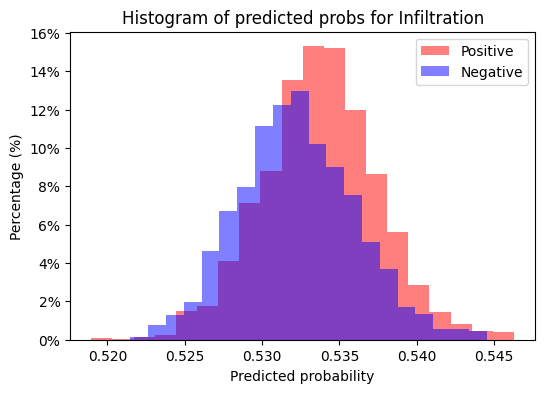

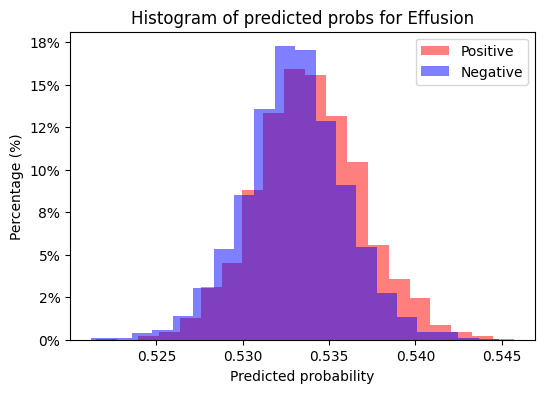

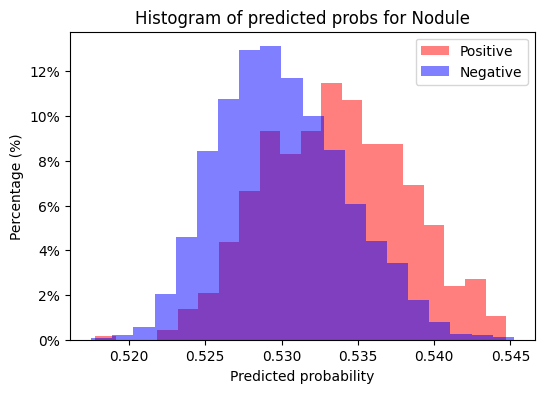

In [ ]:
plot_label_histograms_percent(y_test_true, y_test_pred_prob, label_names)#0.5 luhuit

In [ ]:
epochs = range(1, len(train_losses) + 1)

# ======================
# 2. Loss
# ======================
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# ======================
# 3. Accuracy
# ======================
plt.figure()
plt.plot(epochs, train_Accs, label='Train Accuracy')
plt.plot(epochs, valid_Accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()